In [ ]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from tqdm import tqdm

import lightgbm as lgb
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import roc_curve

# 윈도우 기본 한글 폰트 설정
mpl.rcParams["font.family"] = "Malgun Gothic"  # 맑은 고딕 사용

# 마이너스 깨짐 방지
mpl.rcParams["axes.unicode_minus"] = False  # 음수 기호 정상 출력

In [4]:
# LGBM 설치
!pip install lightgbm scikit-learn shap


  Using cached shap-0.49.1-cp39-cp39-win_amd64.whl (547 kB)
  Using cached slicer-0.0.8-py3-none-any.whl (15 kB)


In [ ]:
"""
# 1. match_meta
meta_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\match_detail\match_meta\*.parquet"
match_meta_df = pd.concat([pd.read_parquet(f) for f in glob.glob(meta_path)], ignore_index=True)

# 2. participants
participants_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\match_detail\participants\*.parquet"
participants_df = pd.concat([pd.read_parquet(f) for f in glob.glob(participants_path)], ignore_index=True)

# 3. teams
teams_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\match_detail\teams\*.parquet"
teams_df = pd.concat([pd.read_parquet(f) for f in glob.glob(teams_path)], ignore_index=True)

# 4. events
events_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\match_timeline\events\*.parquet"
events_df = pd.concat([pd.read_parquet(f) for f in glob.glob(events_path)], ignore_index=True)

# 5. frames
frames_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\match_timeline\frames\*.parquet"
frames_df = pd.concat([pd.read_parquet(f) for f in glob.glob(frames_path)], ignore_index=True)
"""

In [2]:
# Data Load Functions
BASE_PATH = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive"

def load_parquet_recursive(folder_path):
    files = glob.glob(folder_path + "/**/*.parquet", recursive=True)

    if len(files) == 0:
        print("Warning : No parquet files found at", folder_path)
        return pd.DataFrame()

    return pd.concat([pd.read_parquet(f) for f in files],ignore_index=True)

In [3]:
# Load Riot Data
match_meta_df = load_parquet_recursive(os.path.join(BASE_PATH, "Riot_API/match_detail/match_meta"))
participants_df = load_parquet_recursive(os.path.join(BASE_PATH, "Riot_API/match_detail/participants"))
teams_df = load_parquet_recursive(os.path.join(BASE_PATH, "Riot_API/match_detail/teams"))
events_df = load_parquet_recursive(os.path.join(BASE_PATH, "Riot_API/match_timeline/events"))
frames_df = load_parquet_recursive(os.path.join(BASE_PATH, "Riot_API/match_timeline/frames"))

In [21]:
# 메모리 최적화 함수
def reduce_memory_usage(df):

    for col in df.columns:

        if df[col].dtype == "int64":
            df[col] = pd.to_numeric(df[col],downcast="integer")

        if df[col].dtype == "float64":
            df[col] = pd.to_numeric(df[col],downcast="float")

    gc.collect()
    return df

In [4]:
# 전처리 기준대로 전처리
def preprocess_match_data(df):

    if df.empty:
        return df

    if "game_duration" in df.columns:
        df = df[df["game_duration"]>=900]

    if "endOfGameResult" in df.columns:
        df = df[df["endOfGameResult"]=="GameComplete"]

    if "queue_id" in df.columns:
        df = df[df["queue_id"].isin([420,440])]

    if "game_version" in df.columns:

        def version_to_float(v):
            try:
                return float(".".join(str(v).split(".")[:2]))
            except:
                return np.nan

        df["version_float"]=df["game_version"].apply(version_to_float)

        df=df[
            (df["version_float"]>=15.1)&
            (df["version_float"]<=16.2)
        ]

    return df

# 적용
match_meta_df = preprocess_match_data(match_meta_df)
teams_df = preprocess_match_data(teams_df)
participants_df = preprocess_match_data(participants_df)

In [5]:
# 전처리 후 gameEndedInEarlySurrender(조기 서렌 여부) = true 있는지 확인
if "game_ended_in_early_surrender" in participants_df.columns:

    print("True exists:",participants_df["game_ended_in_early_surrender"].eq(True).any())

True exists: False


In [6]:
print(frames_df.columns.tolist())

['match_id', 'platform', 'participant_id', 'timestamp', 'minute', 'level', 'xp', 'total_gold', 'minions_killed', 'jungle_minions_killed', 'time_enemy_spent_controlled', 'dmg_total_done_to_champions', 'dmg_total_taken']


In [22]:
# Early Feature
frames_df["timestamp_min"] = frames_df["timestamp"]/60000

def extract_early_features_stream(frames_df,participants_df,minute=10):

    if frames_df.empty:
        return pd.DataFrame()

    early_frames = frames_df[
        frames_df["timestamp_min"]<=minute
    ].copy()

    early_frames = early_frames.merge(
        participants_df[
            ["match_id","participant_id","team_id"]
        ],
        on=["match_id","participant_id"],
        how="left"
    )

    agg = early_frames.groupby(
        ["match_id","team_id"],
        observed=True
    ).agg({
        "total_gold":"mean",
        "dmg_total_done_to_champions":"mean",
        "minions_killed":"sum",
        "jungle_minions_killed":"sum"
    }).reset_index()

    return reduce_memory_usage(agg)

In [ ]:
# 팀 구조 특징
def extract_team_structure_features(participants_df):

    if participants_df.empty:
        return pd.DataFrame()

    cols = [
        "goldEarned",
        "totalDamageDealtToChampions",
        "deaths",
        "visionScore"
    ]

    exist_cols = [c for c in cols if c in participants_df.columns]

    agg = participants_df.groupby(
        ["match_id","team_id"],
        observed=True
    )[exist_cols].agg(["mean","std","sum"])

    agg.columns = ["_".join(c) for c in agg.columns]

    return reduce_memory_usage(agg.reset_index())

In [24]:
# 이벤트 기반 구조 특징 (Memory Safe)
def extract_event_features_stream(events_df):

    if events_df.empty:
        return pd.DataFrame()

    obj = events_df.copy()

    obj["timestamp_min"] = obj["timestamp"]/60000

    obj_features = obj.groupby(
        ["match_id","team_id","event_type"]
    ).size().unstack(fill_value=0).reset_index()

    return reduce_memory_usage(obj_features)

In [29]:
# Champion Pivot 생성 (포지션 슬롯 구조)
champ_df = participants_df[[
    "match_id",
    "team_id",
    "team_position",
    "champion_name"
]].copy()

champ_pivot = champ_df.pivot_table(
    index=["match_id","team_id"],
    columns="team_position",
    values="champion_name",
    aggfunc="first"
).reset_index()

champ_pivot = champ_pivot.rename(columns={
    "TOP":"top_champ",
    "JUNGLE":"jungle_champ",
    "MIDDLE":"mid_champ",
    "BOTTOM":"adc_champ",
    "UTILITY":"support_champ"
})

In [32]:
print("Feature Dataset 생성 중...")

# Feature 준비
early_timeline_df = extract_early_features_stream(
    frames_df,
    participants_df,
    minute=10
)

team_struct_df = extract_team_structure_features(participants_df)
event_struct_df = extract_event_features_stream(events_df)

def build_final_dataset():

    df = teams_df.copy()

    feature_dfs = [
        early_timeline_df,
        team_struct_df,
        champ_pivot,
        event_struct_df
    ]

    for fdf in tqdm(feature_dfs, desc="Feature Merge"):

        if fdf is None or fdf.empty:
            continue

        df = df.merge(
            fdf,
            on=["match_id","team_id"],
            how="left"
        )

        df = reduce_memory_usage(df)

        gc.collect()

    return df


final_df = build_final_dataset()

Feature Dataset 생성 중...


MemoryError: Unable to allocate 767. MiB for an array with shape (9, 11166970) and data type float64

In [26]:
# Comment 데이터 분석
print("Comment Load")

df_kor = pd.read_csv(os.path.join(BASE_PATH,"Youtube/youtube_국내.csv"))
df_over = pd.read_csv(os.path.join(BASE_PATH,"Youtube/youtube_해외(번역본).csv"))
df_trans = pd.read_csv(os.path.join(BASE_PATH,"Reddit/translated_progress_gcloud_ver.csv"))

df_kor["comment"] = df_kor["comment_text"]
df_over["comment"] = df_over["comment_text"]
df_trans["comment"] = df_trans["translated_text"]

df_kor["source"] = "youtube_kor"
df_over["source"] = "youtube_overseas"
df_trans["source"] = "reddit"

df_all = pd.concat([df_kor,df_over,df_trans],ignore_index=True)

df_all = df_all.dropna(subset=["comment"])

df_all["clean_comment"] = df_all["comment"].astype(str).str.lower()

Comment Load


In [27]:
print("Participants Columns:")
print(participants_df.columns.tolist())

print("\nTeams Columns:")
print(teams_df.columns.tolist())

print("\nFrames Columns:")
print(frames_df.columns.tolist())

Participants Columns:
['match_id', 'platform', 'participant_id', 'puuid', 'team_id', 'team_position', 'individual_position', 'role', 'champion_id', 'champion_name', 'champ_experience', 'champ_level', 'win', 'kills', 'deaths', 'assists', 'killing_sprees', 'total_damage_dealt', 'total_damage_dealt_to_champions', 'total_damage_taken', 'damage_self_mitigated', 'total_time_spent_dead', 'total_time_cc_dealt', 'time_ccing_others', 'gold_earned', 'gold_spent', 'total_minions_killed', 'neutral_minions_killed', 'total_ally_jungle_minions_killed', 'total_enemy_jungle_minions_killed', 'time_played', 'baron_kills', 'dragon_kills', 'damage_dealt_to_buildings', 'damage_dealt_to_epic_monsters', 'damage_dealt_to_objectives', 'damage_dealt_to_turrets', 'turret_takedowns', 'turret_plates_taken', 'inhibitor_takedowns', 'objectives_stolen', 'objectives_stolen_assists', 'vision_score', 'wards_placed', 'wards_killed', 'detector_wards_placed', 'vision_wards_bought_in_game', 'game_ended_in_early_surrender', 'g

In [12]:
# Champion Pivot 생성
champ_df = participants_df[[
    "match_id",
    "team_id",
    "team_position",
    "champion_name"
]].copy()

champ_pivot = champ_df.pivot_table(
    index=["match_id","team_id"],
    columns="team_position",
    values="champion_name",
    aggfunc="first"
).reset_index()

champ_pivot.columns.name = None

champ_pivot = champ_pivot.rename(columns={
    "TOP":"top_champ",
    "JUNGLE":"jungle_champ",
    "MIDDLE":"mid_champ",
    "BOTTOM":"adc_champ",
    "UTILITY":"support_champ"
})

In [13]:
# Feature Dataset 생성
def build_final_dataset():
    df = teams_df.copy()

    df = df.merge(early_timeline_df,on=["match_id","team_id"],how="left")
    df = df.merge(team_struct_df,on=["match_id","team_id"],how="left")
    df = df.merge(champ_pivot,on=["match_id","team_id"],how="left")

    return df

final_df = build_final_dataset()
print("Final Shape:", final_df.shape)

Final Shape: (159294, 39)


In [14]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

In [19]:
TARGET = "win"

# 불필요한 컬럼 제거
drop_cols = [
    "match_id",
    "team_id",
    "platform",
    "game_version",
    "game_mode",
    "game_creation",
    TARGET
]

# 존재하는 컬럼만 drop (에러 방지)
drop_cols = [c for c in drop_cols if c in final_df.columns]

base_df = final_df.drop(columns=drop_cols).copy()

# categorical_cols 설정
categorical_cols = [
    "top_champ",
    "jungle_champ",
    "mid_champ",
    "adc_champ",
    "support_champ"
]

# bool/object 안전 변환

# "_first" 로 끝나는 오브젝트 컬럼 bool 변환
for col in base_df.columns:
    if col.endswith("_first") and base_df[col].dtype == "object":
        base_df[col] = base_df[col].map({"True": True, "False": False})

# X / y 분리
X = base_df.copy()
y = final_df[TARGET]

# 희귀 챔피언 묶기 (1% 미만)
for col in categorical_cols:
    if col in X.columns:
        freq = X[col].value_counts(normalize=True)
        rare = freq[freq < 0.01].index
        X[col] = X[col].replace(rare, "Other")

# category 타입 변환
for col in categorical_cols:
    if col in X.columns:
        X[col] = X[col].astype("category")

# object 타입 완전 제거
for col in X.columns:
    if X[col].dtype == "object" and col not in categorical_cols:
        X.drop(columns=[col], inplace=True)

# NaN 처리
numeric_cols = X.select_dtypes(include=["int64","float64","bool"]).columns
X[numeric_cols] = X[numeric_cols].fillna(0)

print("최종 X shape:", X.shape)
print("남은 object 컬럼:", X.select_dtypes(include="object").columns.tolist())

최종 X shape: (159294, 30)
남은 object 컬럼: []


In [ ]:
X.dtypes.value_counts()

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [21]:
model = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=256,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)

[LightGBM] [Info] Number of positive: 63715, number of negative: 63720
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006728 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2071
[LightGBM] [Info] Number of data points in the train set: 127435, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499980 -> initscore=-0.000078
[LightGBM] [Info] Start training from score -0.000078


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.01, n_estimators=2000,
               num_leaves=256, random_state=42, subsample=0.8)

In [22]:
# 예측
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, pred_proba)

print("===== 모델 성능 =====")
print("Accuracy :", acc)
print("AUC :", auc)

===== 모델 성능 =====
Accuracy : 0.9714052544022097
AUC : 0.9962750035990293


In [23]:
# 테스트 데이터 결과 저장용 데이터프레임 생성
result_df = X_test.copy()

result_df["true_label"] = y_test.values
result_df["pred_label"] = pred
result_df["pred_probability"] = pred_proba

# 저장
result_df.to_csv("lgbm_prediction_result.csv", index=False, encoding="utf-8-sig")
print("===== 예측 결과 CSV 저장 완료 =====")

===== 예측 결과 CSV 저장 완료 =====


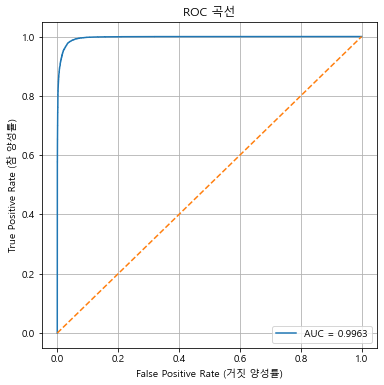

In [25]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, pred_proba)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate (거짓 양성률)")
plt.ylabel("True Positive Rate (참 양성률)")
plt.title("ROC 곡선")

plt.legend()
plt.grid(True)
plt.show()

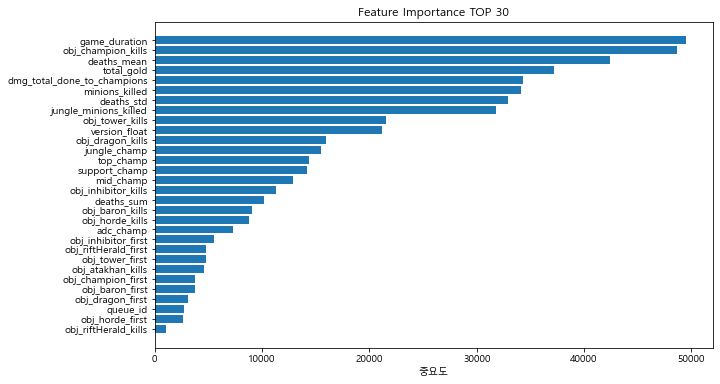

In [26]:
# Feature Importance Top 30
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importances = importances.sort_values("importance", ascending=False).head(30)

plt.figure(figsize=(10,6))
plt.barh(importances["feature"], importances["importance"])

plt.title("Feature Importance TOP 30")
plt.xlabel("중요도")

plt.gca().invert_yaxis()
plt.show()

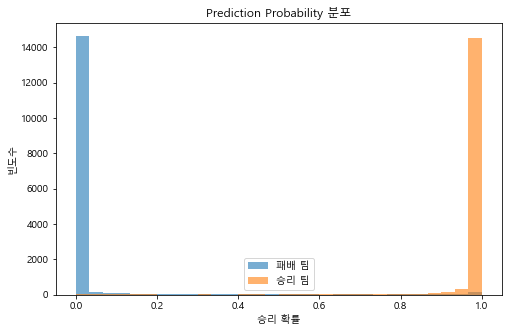

In [27]:
#Prediction Distribution
plt.figure(figsize=(8,5))

plt.hist(pred_proba[y_test==0], bins=30, alpha=0.6, label="패배 팀")
plt.hist(pred_proba[y_test==1], bins=30, alpha=0.6, label="승리 팀")

plt.title("Prediction Probability 분포")
plt.xlabel("승리 확률")
plt.ylabel("빈도수")
plt.legend()

plt.show()

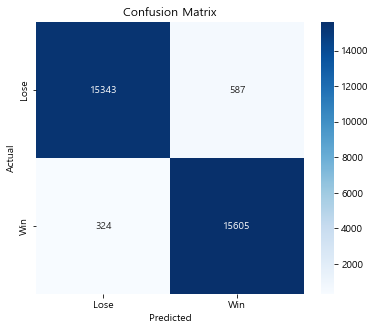

In [28]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Lose","Win"],
    yticklabels=["Lose","Win"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

SHAP Explainer 생성 중...
Explainer 생성 완료

SHAP 값 계산 시작...



SHAP 계산 진행률: 100%|███████████████████████████████████████████| 160/160 [43:21<00:00, 16.26s/it]



===== SHAP 계산 완료 =====


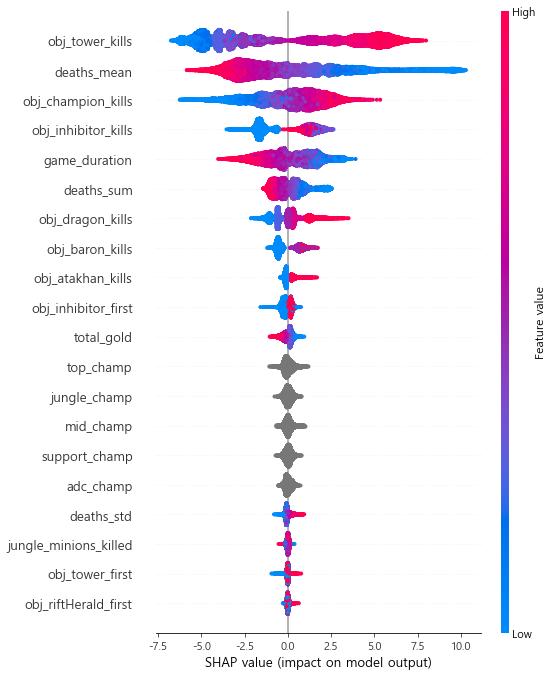

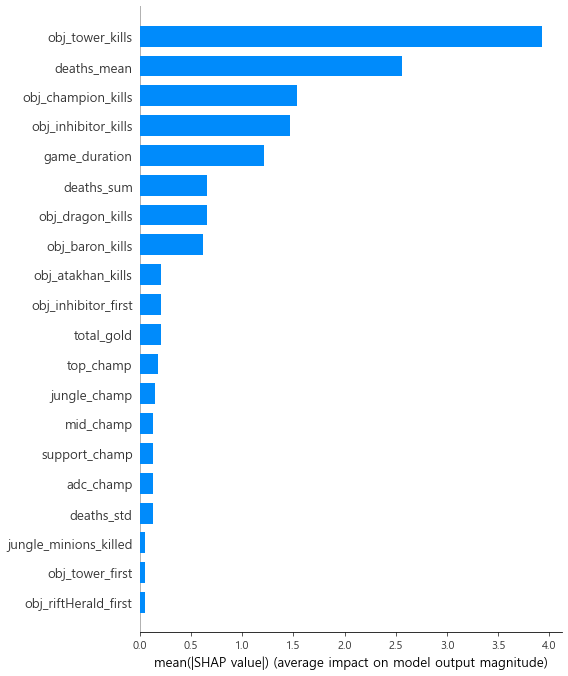

In [32]:
# SHAP Explainer 생성
print("SHAP Explainer 생성 중...")
explainer = shap.TreeExplainer(model,feature_perturbation="tree_path_dependent")

print("Explainer 생성 완료\n")

print("SHAP 값 계산 시작...\n")

chunk_size = 200   # 메모리에 따라 100~500 조절
shap_values_list = []

for start in tqdm(range(0, len(X_test), chunk_size), 
                  desc="SHAP 계산 진행률", 
                  ncols=100):
    
    end = start + chunk_size
    
    # DataFrame 그대로 슬라이싱
    shap_chunk = explainer.shap_values(X_test.iloc[start:end])
    
    # binary 분류면 보통 [0], [1] 중 승리 클래스 선택
    if isinstance(shap_chunk, list):
        shap_chunk = shap_chunk[1]
    
    shap_values_list.append(shap_chunk)

# 합치기
shap_values = np.vstack(shap_values_list)
print("\n===== SHAP 계산 완료 =====")

#explainer = shap.TreeExplainer(model)
#shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test,
    show=True
)

# SHAP 중요도 Bar Plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=True
)

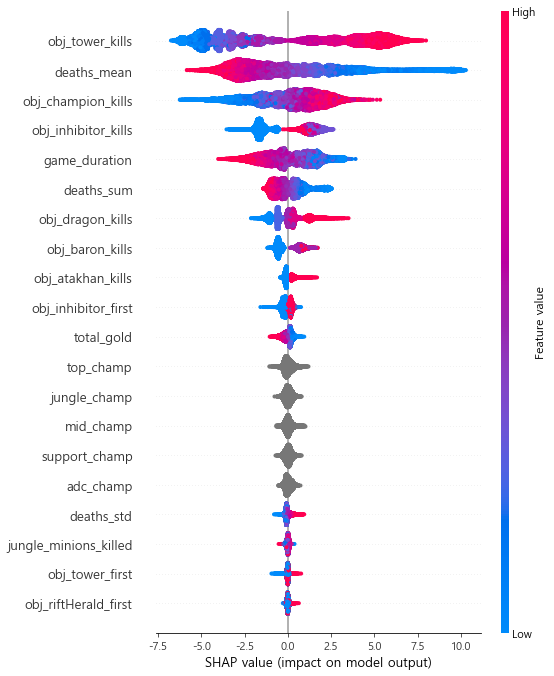

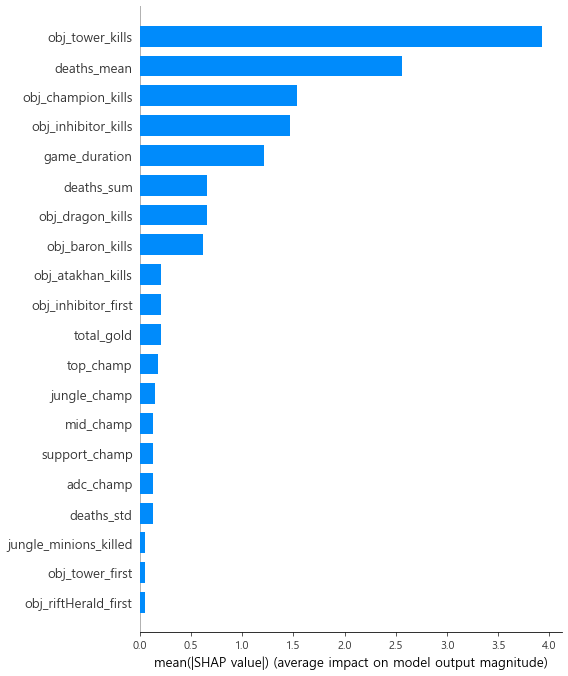

In [33]:
#explainer = shap.TreeExplainer(model)
#shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test,
    show=True
)

# SHAP 중요도 Bar Plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=True
)

In [54]:
df_kor = pd.read_csv(r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\Youtube\youtube_국내.csv")
df_over = pd.read_csv(r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\Youtube\youtube_해외(번역본).csv")
df_trans = pd.read_csv(r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\Reddit\translated_progress_gcloud_ver.csv")

print("국내 유튜브 컬럼")
print(df_kor.columns)
print("\n해외 유튜브 번역본 컬럼")
print(df_over.columns)
print("\nReddit 번역본 컬럼")
print(df_trans.columns)

국내 유튜브 컬럼
Index(['playlist_title', 'video_id', 'title', 'description',
       'publish_time_utc', 'viewCount', 'likeCount', 'commentCount',
       'comment_text', 'comment_likeCount'],
      dtype='object')

해외 유튜브 번역본 컬럼
Index(['playlist_title', 'video_id', 'title', 'description', 'Date Posted',
       'viewCount', 'likeCount', 'commentCount', 'comment_text',
       'comment_likeCount', 'has_emoji'],
      dtype='object')

Reddit 번역본 컬럼
Index(['subreddit', 'post_id', 'post_title', 'post_created_dt', 'post_score',
       'post_num_comments', 'comment_id', 'comment_author', 'comment_score',
       'comment_created_dt', 'comment_body_raw', 'comment_body_clean',
       'emoji_list', 'emoji_count', 'language', 'has_emoji',
       'translated_text'],
      dtype='object')


In [55]:
# comment 컬럼 통일
df_kor["comment"] = df_kor["comment_text"]
df_over["comment"] = df_over["comment_text"]
df_trans["comment"] = df_trans["translated_text"]

# 출처 구분 컬럼 추가
df_kor["source"] = "youtube_kor"
df_over["source"] = "youtube_overseas"
df_trans["source"] = "reddit"

# 공통 컬럼만 남기기
common_cols = ["comment", "source"]

df_kor = df_kor[common_cols]
df_over = df_over[common_cols]
df_trans = df_trans[common_cols]

# 통합
df_all = pd.concat([df_kor, df_over, df_trans], ignore_index=True)

print("총 댓글 수:", len(df_all))
print(df_all["source"].value_counts())

총 댓글 수: 152950
reddit              117498
youtube_kor          24889
youtube_overseas     10563
Name: source, dtype: int64


In [56]:
import re

# 결측치 제거
df_all = df_all.dropna(subset=["comment"]).copy()

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^가-힣a-z0-9\s:]", " ", text)
    return text.strip()

df_all["clean_comment"] = df_all["comment"].apply(clean_text)

print("정제 후 댓글 수:", len(df_all))

정제 후 댓글 수: 152946


In [57]:
# 정의(변형 포함)
alias_dict = {
    "그레이브즈": ["그브"],
    "모르가나": ["몰가","모르"],
    "이즈리얼": ["이즈"],
    "이렐리아": ["이렐","이랠"],
    "아우렐리온 솔": ["아우솔","아솔"],
    "블리츠크랭크": ["블츠","블크"],
    "블라디미르": ["블라디"],
    "알리스타": ["알리"],
    "트리스타나": ["트타"],
    "트린다미어": ["트린","트린다"],
    "리 신": ["리신"],
    "미스 포츈": ["미포"],
    "누누와 윌럼프": ["누누윌럼프", "누누"],
    "레나타 글라스크": ["레나타"],
    "케이틀린": ["케틀","캐틀"],
    "마스터 이": ["마이"],
    "트위스티드 페이트": ["트페"],
    "카타리나": ["카타"],
    "카직스": ["카직스"],
    "자르반 4세": ["자르반", "잘반"],
}

position_dict = {
    "탑": ["탑"],
    "정글": ["정글", "정글러"],
    "미드": ["미드"],
    "원거리 딜러": ["원거리 딜러", "원딜", "바텀"],
    "서포터": ["서포터", "서폿"]
}

cause_keywords = [
    "부담", "압박", "책임",
    "격차", "차이", "밀리",
    "시야", "와드", "맵",
    "자동 배정", "오토필"
]

positive_keywords = [
    "좋", "잘", "강",
    "사기", "캐리", "쎄",
    "재밌", "괜찮", "최고",
    "든든", "완벽", "쉽다",
    "편안", "공감", "강력",
    "안전", "추천", "자랑",
    "유용", "적합", "효과적",
    "장인"
]

performance_keywords = [
    "딜", "데미지", "kda",
    "시야 점수", "오브젝트",
    "골드", "cs", "아이템", "갱"
]

negative_keywords = [
    "망","망겜", "별로", "문제",
    "불공평", "어렵", "힘들",
    "어려", "사고", "짜증",
    "싫어","싫었","도무지",
    "답답","빌어먹을","없던",
    "안돼","안 돼","없애",
    "트롤","모욕","더러운",
    "좁아","없네","최악",
    "않은", "못","없는",
    "끔찍", "착각",
    "부족","없","슬픈",
    "박살", "쓰레기", "까다롭",
    "카이팅","욕","무시",
    "증오","슬퍼","안타깝",
    "망상","종료", "떨어진"
]

stress_keywords = [
    "스트레스", "짜증", "화남",
    "피곤", "지침", "지쳐",
    "답답","증오"
]

In [58]:
print(X.columns)

Index(['source', 'neg_count', 'pos_count', 'stress_count', 'cause_count',
       'perf_count', 'mention_그레이브즈', 'mention_모르가나', 'mention_이즈리얼',
       'mention_이렐리아', 'mention_아우렐리온 솔', 'mention_블리츠크랭크', 'mention_블라디미르',
       'mention_알리스타', 'mention_트리스타나', 'mention_트린다미어', 'mention_리 신',
       'mention_미스 포츈', 'mention_누누와 윌럼프', 'mention_레나타 글라스크', 'mention_케이틀린',
       'mention_마스터 이', 'mention_트위스티드 페이트', 'mention_카타리나', 'mention_카직스',
       'mention_자르반 4세', 'mention_탑', 'mention_정글', 'mention_미드',
       'mention_원거리 딜러', 'mention_서포터', 'complaint_index'],
      dtype='object')


In [61]:
print(df_all.columns)

Index(['comment', 'source', 'clean_comment'], dtype='object')


In [62]:
def keyword_count(text, keywords):
    return sum(text.count(k) for k in keywords)

# 감정 피처 생성
df_all["neg_count"] = df_all["clean_comment"].apply(lambda x: keyword_count(x, negative_keywords))
df_all["pos_count"] = df_all["clean_comment"].apply(lambda x: keyword_count(x, positive_keywords))
df_all["stress_count"] = df_all["clean_comment"].apply(lambda x: keyword_count(x, stress_keywords))
df_all["cause_count"] = df_all["clean_comment"].apply(lambda x: keyword_count(x, cause_keywords))
df_all["perf_count"] = df_all["clean_comment"].apply(lambda x: keyword_count(x, performance_keywords))

In [63]:
# 감성 구조 분석 프로젝트 = 설명형 + 지수 분석으로 활용
"""
어떤 챔피언이 가장 불만을 유발하는가?
포지션별 스트레스 언급은 어디가 높은가?
성능 언급은 긍정과 연결되는가, 부정과 연결되는가?
국내 vs 해외 감정 차이는?
"""
# target 삭제
if "target" in df_all.columns:
    df_all = df_all.drop(columns=["target"])

In [64]:
# Complaint Index를 종속지표로 사용 (회귀) - 불만 강도 점수
df_all["complaint_index"] = (
    df_all["neg_count"] * 2 +
    df_all["stress_count"] * 1.5 +
    df_all["cause_count"]
)

In [68]:
# 모델은 텍스트 원문이 필요 없어서 드랍
drop_cols = ["comment", "clean_comment"]

X = df_all.drop(columns=drop_cols + ["complaint_index"])
y = df_all["complaint_index"]

In [75]:
# df_all 존재하는지 확인
print("df_all 존재:", "df_all" in globals())

print("컬럼 목록:")
print(df_all.columns)

print("\n현재 데이터 타입:")
print(df_all.dtypes)

df_all 존재: True
컬럼 목록:
Index(['comment', 'source', 'clean_comment', 'neg_count', 'pos_count',
       'stress_count', 'cause_count', 'perf_count', 'complaint_index'],
      dtype='object')

현재 데이터 타입:
comment             object
source              object
clean_comment       object
neg_count            int64
pos_count            int64
stress_count         int64
cause_count          int64
perf_count           int64
complaint_index    float64
dtype: object


In [69]:
X = pd.get_dummies(X, columns=["source"], drop_first=True)

In [76]:
from lightgbm import LGBMRegressor

# 모델에 쓸 컬럼만 명확히 지정
feature_cols = [
    "neg_count",
    "pos_count",
    "stress_count",
    "cause_count",
    "perf_count"
]

# source는 원핫 인코딩으로 처리
df_model = pd.get_dummies(df_all[feature_cols + ["source"]], drop_first=True)

X = df_model.copy()
y = df_all["complaint_index"].copy()

print("===== X 확인 =====")
print(X.dtypes)
print(X.head())

# 모델 학습
model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

model.fit(X, y)

print("모델 학습 완료")

===== X 확인 =====
neg_count                  int64
pos_count                  int64
stress_count               int64
cause_count                int64
perf_count                 int64
source_youtube_kor         uint8
source_youtube_overseas    uint8
dtype: object
   neg_count  pos_count  stress_count  cause_count  perf_count  \
0          0          0             0            0           0   
1          1          0             0            0           0   
2          0          0             0            0           0   
3          0          3             0            0           1   
4          1          0             0            0           0   

   source_youtube_kor  source_youtube_overseas  
0                   1                        0  
1                   1                        0  
2                   1                        0  
3                   1                        0  
4                   1                        0  
[LightGBM] [Info] Auto-choosing row-wise multi-

In [77]:
# 피처 중요도 전체 구조 파악 - 상위 3개
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df)

                   feature  importance
0                neg_count        3225
3              cause_count        2720
2             stress_count        1425
1                pos_count         991
4               perf_count         619
5       source_youtube_kor          20
6  source_youtube_overseas           0


SHAP 계산 진행률: 100%|██████████| 77/77 [00:50<00:00,  1.53it/s]


===== 전체 SHAP 계산 완료 =====
SHAP shape: (152946, 7)


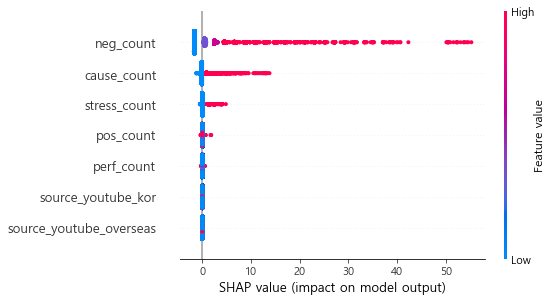

In [78]:
explainer = shap.TreeExplainer(model)

# numpy array로 변환 (속도 개선)
X_array = X.values

batch_size = 2000  # 너무 크면 느림, 1000~3000 사이 추천
shap_values_list = []

total_batches = int(np.ceil(len(X_array) / batch_size))

for i in tqdm(range(total_batches), desc="SHAP 계산 진행률"):
    
    start = i * batch_size
    end = min((i + 1) * batch_size, len(X_array))
    
    shap_batch = explainer.shap_values(X_array[start:end])
    shap_values_list.append(shap_batch)

# 전체 합치기
shap_values = np.vstack(shap_values_list)

print("===== 전체 SHAP 계산 완료 =====")
print("SHAP shape:", shap_values.shape)

shap.summary_plot(shap_values, X)

In [ ]:
# youtube, reddit 데이터 tableau용으로 저장
# source별 평균 불만 지수
source_summary = df_all.groupby("source")["complaint_index"].mean().reset_index()
source_summary.to_csv("tableau_source_summary.csv", index=False, encoding="utf-8-sig")

# 감정 평균
emotion_summary = df_all[[
    "neg_count",
    "pos_count",
    "stress_count",
    "cause_count",
    "perf_count"
]].mean().reset_index()

emotion_summary.to_csv("tableau_emotion_summary.csv", index=False, encoding="utf-8-sig")